
# Module 25: DBSCAN & Hierarchical Clustering

This notebook is designed for hands-on practice.



## Dataset 1: Blob Dataset with Different Densities

This dataset contains clusters with different densities.
DBSCAN should behave differently for each cluster.


[[ 5.10154892  4.87541363]
 [ 4.86498036  5.18685498]
 [ 4.84318309  5.31470277]
 [ 5.00849551  5.00892684]
 [ 4.70311855  4.96226392]
 [ 4.98870959  5.33099056]
 [ 5.92366424  5.33587247]
 [ 0.93617973  0.94251826]
 [-4.8955682  -5.97983506]
 [-5.42339686 -5.75742361]
 [ 5.0996942   4.77545404]
 [-5.03855085 -4.82942401]
 [ 4.76786324  4.62660359]
 [-4.8193022  -4.23098172]
 [-4.9698849  -3.76837894]
 [-4.8712248  -5.03722296]
 [ 5.08113705  4.98492857]
 [-0.16314022  0.60256758]
 [-5.45401204 -5.70615185]
 [-4.74750636 -4.5671224 ]
 [-5.4042468  -5.25087852]
 [ 5.07680892  5.2948073 ]
 [ 4.80602813  4.6755356 ]
 [ 5.14799537  5.05545084]
 [-4.71455474 -4.43221718]
 [-4.87475357 -4.8267759 ]
 [ 5.03281844  5.21772999]
 [ 5.12403047  5.56303874]
 [-4.85193986 -4.86947236]
 [ 4.57774649  4.76665499]
 [ 4.80444917  5.0142196 ]
 [ 4.20470906  5.32745206]
 [-4.48450024 -4.53435994]
 [-4.81918199 -5.32255988]
 [ 4.79008235  5.06419397]
 [-5.22002224 -4.93462971]
 [-5.53115186 -4.76320378]
 

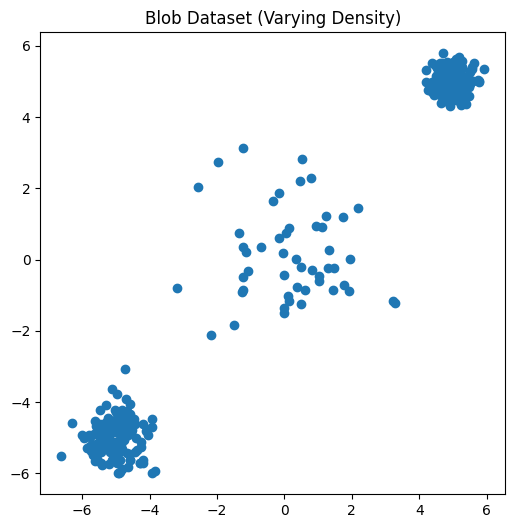

In [ ]:
#Done for you
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

X_blobs, _ = make_blobs(
    n_samples=[150, 50, 200],
    centers=[(-5, -5), (0, 0), (5, 5)],
    cluster_std=[0.5, 1.5, 0.3],
    random_state=42
)
print(X_blobs)
plt.figure(figsize=(6,6))
plt.scatter(X_blobs[:,0], X_blobs[:,1])
plt.title("Blob Dataset (Varying Density)")
plt.show()


### TODO 1: Scaling

Scale the dataset using StandardScaler.

Think:
- Why is scaling important here?
- What happens if we skip scaling?


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_blobs
import pandas as pd

# Ensure data is generated if kernel was restarted


# TODO: Scale the dataset and verify that the mean is ~0 and variance is ~1

# Challenge: Check the summary statistics of the scaled data


scaler= StandardScaler()
X_scaled = scaler.fit_transform(X_blobs)
print(X_scaled)

[[ 0.95652501  0.90783176]
 [ 0.9058811   0.97463543]
 [ 0.9012148   1.00205857]
 [ 0.9366044   0.93647013]
 [ 0.87123019  0.92646101]
 [ 0.93236869  1.00555228]
 [ 1.13252106  1.00659944]
 [ 0.0648149   0.0642321 ]
 [-1.18362872 -1.42060144]
 [-1.29662474 -1.37289454]
 [ 0.95612796  0.8863906 ]
 [-1.21423803 -1.17384014]
 [ 0.88509055  0.85446242]
 [-1.16730192 -1.04547524]
 [-1.19953822 -0.94624769]
 [-1.17841736 -1.21841267]
 [ 0.95215529  0.93132254]
 [-0.17052432 -0.00868677]
 [-1.30317875 -1.36189683]
 [-1.15193207 -1.11757687]
 [-1.29252515 -1.26424144]
 [ 0.95122874  0.99779103]
 [ 0.89326078  0.86495825]
 [ 0.96646813  0.94644945]
 [-1.14487789 -1.08863992]
 [-1.17917279 -1.17327212]
 [ 0.94181139  0.98125807]
 [ 0.96133779  1.05532624]
 [-1.17428889 -1.18243044]
 [ 0.84439091  0.88450322]
 [ 0.89292276  0.93760542]
 [ 0.76453214  1.00479327]
 [-1.09562849 -1.11054937]
 [-1.16727618 -1.27961698]
 [ 0.88984715  0.94832484]
 [-1.2530869  -1.19640659]
 [-1.31969262 -1.15963601]
 

In [ ]:
from sklearn.preprocessing import StandardScaler
import numpy as np

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_blobs)

print("Mean:")
print(np.mean(X_scaled, axis=0))

print("\nVariance:")
print(np.var(X_scaled, axis=0))  # ata just question e bolse tai check kora

Mean:
[ 7.60502772e-17 -6.77236045e-17]

Variance:
[1. 1.]


In [ ]:
import pandas as pd

df_scaled = pd.DataFrame(X_scaled)

df_scaled.describe()   # x_scaled ta numpy array tai describe name e kico nai akne

,0,1
count,4.000000e+02,4.000000e+02
mean,5.773160e-17,-6.439294e-17
std,1.001252e+00,1.001252e+00
min,-1.552926e+00,-1.423594e+00
25%,-1.172044e+00,-1.159617e+00
50%,6.645817e-01,6.608559e-01
75%,9.330801e-01,9.311268e-01
max,1.132521e+00,1.103948e+00



### TODO 2: DBSCAN on Blob Dataset

Apply DBSCAN.
Experiment with different values of eps and min_samples.


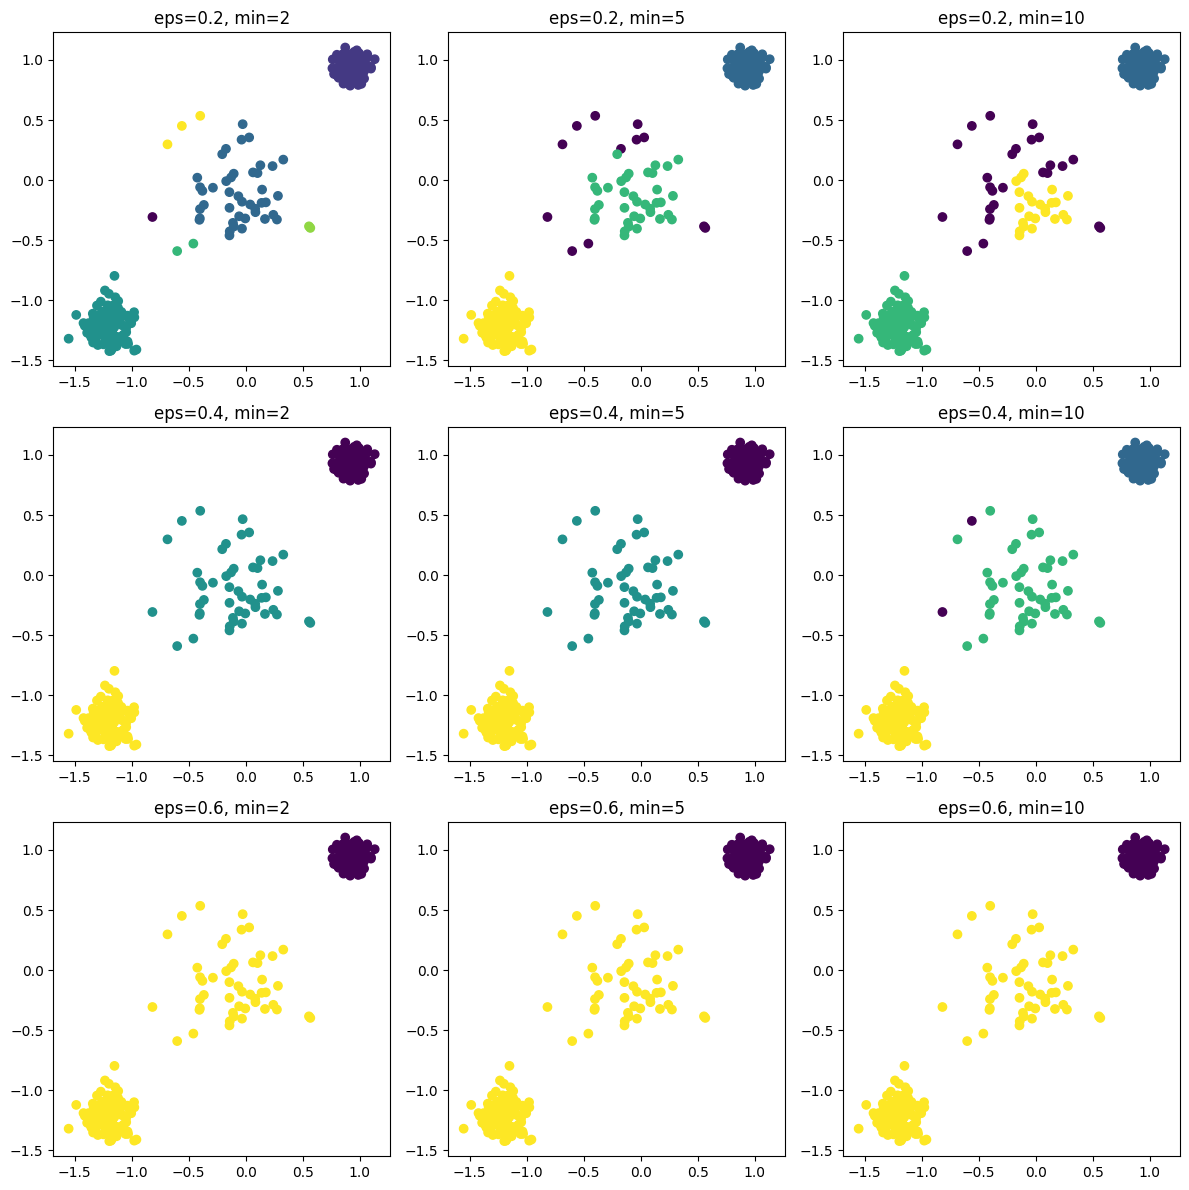

In [ ]:
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt
import numpy as np

# TODO: Implement DBSCAN
# Challenge: Create a function that loops through a grid of eps [0.2, 0.4, 0.6]
# and min_samples [2, 5, 10] and plots the results in a 3x3 subplot grid.

from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

eps_values = [0.2, 0.4, 0.6]
min_samples_values = [2, 5, 10]

plt.figure(figsize=(12,12))

plot_no = 1

for eps in eps_values:
    for min_sample in min_samples_values:

        dbscan = DBSCAN(eps=eps, min_samples=min_sample)

        dbscan.fit(X_scaled)

        label_dbscan = dbscan.labels_

        plt.subplot(3,3,plot_no)
        plt.scatter(X_scaled[:,0], X_scaled[:,1], c=label_dbscan, cmap="viridis")
        plt.title(f"eps={eps}, min={min_sample}")

        plot_no += 1

plt.tight_layout()
plt.show()


### TODO 3: k-Distance Plot

Use a k-distance plot to estimate eps.


In [ ]:
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import numpy as np
import sklearn.metrics as metrics
import pandas as pd
from sklearn.cluster import KMeans
# TODO: Create k-distance plot
# Challenge: Use the 'knee' point detection logic.
# Calculate distances to the 5th nearest neighbor, sort them, and plot.

kmeans=KMeans(
    n_clusters=4,
    init="k-means++",
    max_iter=300,
    random_state=42)


kmeans.fit(X_scaled)
label_kmeans=kmeans.labels_
label_kmeans

array([3, 1, 1, 3, 1, 3, 3, 2, 0, 0, 3, 0, 1, 0, 0, 0, 3, 2, 0, 0, 0, 3,
       1, 3, 0, 0, 3, 3, 0, 1, 1, 1, 0, 0, 1, 0, 0, 3, 0, 3, 0, 0, 3, 0,
       3, 0, 0, 3, 0, 3, 3, 2, 3, 3, 0, 1, 1, 1, 3, 1, 1, 0, 3, 3, 0, 3,
       1, 1, 0, 0, 3, 0, 2, 1, 2, 0, 0, 0, 0, 2, 1, 1, 1, 3, 3, 0, 2, 3,
       1, 2, 1, 3, 1, 0, 3, 1, 0, 3, 3, 3, 3, 3, 1, 3, 3, 0, 0, 0, 3, 1,
       1, 3, 2, 3, 0, 0, 0, 3, 0, 3, 0, 1, 3, 1, 0, 1, 0, 0, 0, 2, 3, 3,
       3, 0, 2, 0, 3, 0, 2, 3, 1, 0, 3, 0, 2, 0, 1, 0, 1, 0, 3, 0, 1, 0,
       0, 0, 0, 0, 2, 2, 0, 1, 1, 3, 3, 3, 3, 0, 3, 3, 1, 0, 0, 0, 0, 2,
       1, 0, 2, 3, 2, 1, 0, 1, 2, 0, 3, 3, 0, 1, 1, 1, 1, 3, 1, 2, 0, 3,
       0, 0, 2, 3, 0, 3, 1, 0, 2, 0, 0, 2, 3, 3, 0, 0, 0, 1, 0, 1, 2, 3,
       0, 3, 0, 3, 0, 1, 0, 3, 3, 3, 1, 1, 3, 0, 3, 0, 0, 0, 3, 1, 0, 0,
       3, 2, 2, 2, 0, 1, 2, 1, 0, 1, 0, 2, 0, 3, 3, 0, 2, 0, 1, 1, 1, 3,
       0, 2, 0, 3, 3, 0, 0, 3, 0, 0, 2, 3, 0, 0, 1, 3, 0, 0, 3, 1, 1, 2,
       0, 3, 0, 0, 3, 3, 0, 0, 0, 1, 3, 2, 1, 1, 0,

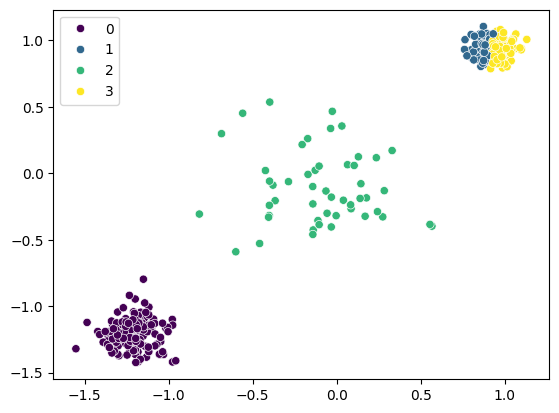

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.scatterplot(x = X_scaled[: ,0] , y =X_scaled[: ,1] , hue = label_kmeans ,palette = 'viridis' )

plt.show()


## Dataset 2: Circular Dataset

This dataset contains non-linear circular clusters.


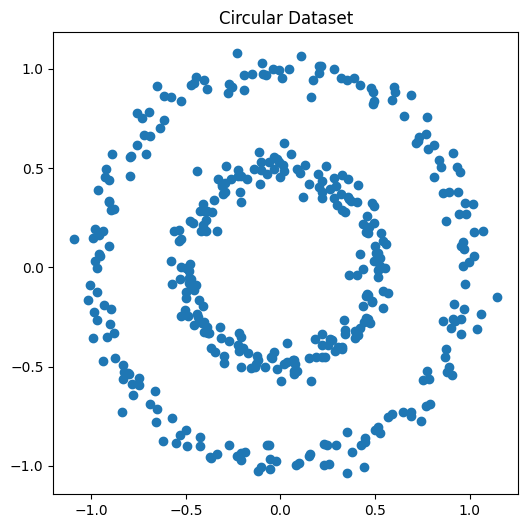

In [ ]:
#Done for you
from sklearn.datasets import make_circles

X_circles, _ = make_circles(
    n_samples=400,
    factor=0.5,
    noise=0.05,
    random_state=42
)

plt.figure(figsize=(6,6))
plt.scatter(X_circles[:,0], X_circles[:,1])
plt.title("Circular Dataset")
plt.show()


### TODO 4: DBSCAN on Circular Data

Apply DBSCAN and observe cluster shape.


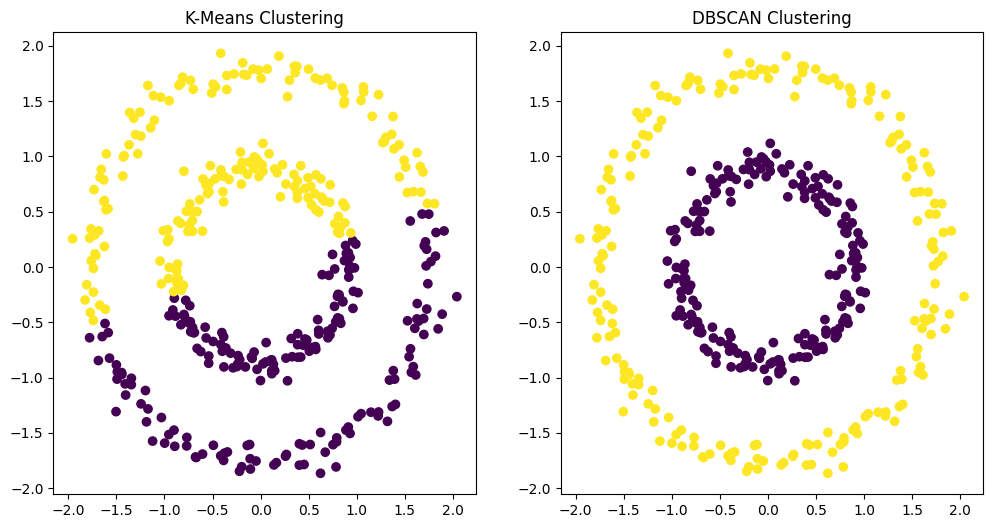

In [ ]:
from sklearn.cluster import KMeans, DBSCAN
from sklearn.datasets import make_circles
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Ensure data is generated

# TODO: Compare DBSCAN results side-by-side with K-Means (k=2)

# KMeans (Expect failure for non-convex shapes)

# DBSCAN (Expect success for dense regions)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_circles)
X_scaled

# kmeans
kmeans=KMeans(
    n_clusters=2,
    init="k-means++",
    max_iter=300,
    random_state=42)


kmeans.fit(X_scaled)
label_kmeans=kmeans.labels_

#dbscan

dbscan = DBSCAN(eps=0.3, min_samples=4)
dbscan.fit(X_scaled)
label_dbscan = dbscan.labels_

plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=label_kmeans, cmap="viridis")
plt.title("K-Means Clustering")
plt.subplot(1,2,2)
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=label_dbscan, cmap="viridis")
plt.title("DBSCAN Clustering")
plt.show()



## Hierarchical Clustering Practice



### TODO 5: Agglomerative Clustering

Try different linkage methods:
single, complete, average, ward


In [ ]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import AgglomerativeClustering

# TODO: Apply hierarchical clustering
# Challenge: For each linkage method, calculate the Silhouette Score.




### TODO 6: Dendrogram

Create a dendrogram using Ward linkage.


In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage

# TODO: Create dendrogram here

## The Grand Challenge: 3D Density Optimization

In this final, hard challenge, we will step into 3D space and automate our parameter selection.

### Requirements:
1. **Generate 3D Data**: Use `make_blobs` to create 1000 samples in 3D space with varying standard deviations.
2. **Parameter Grid Search**: Write a loop that tests `eps` from 0.1 to 1.0 and `min_samples` from 2 to 10.
3. **Optimization**: Find the combination that maximizes the `silhouette_score` (excluding noise points).
4. **3D Visualization**: Plot the final optimized clusters using a 3D scatter plot.